# FincaMarket — Recomendador de Propiedades
## Collaborative Filtering con TruncatedSVD

**Stack:** `numpy` · `pandas` · `scikit-learn` · `matplotlib` · `seaborn` · `joblib`

| | |
|---|---|
| Catálogo | 20 propiedades reales de FincaMarket |
| Usuarios sintéticos | 1.000 |
| Segmentos comportamentales | 6 |
| Modelo | TruncatedSVD (n_components=6) |
| Métricas | Precision@3 · Recall@3 |
| Output | `fincamarket_recommender.pkl` |

---
## Setup — Imports y catálogo de propiedades

In [17]:
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import date

np.random.seed(42)

import sklearn
print(f'numpy {np.__version__}  |  sklearn {sklearn.__version__}  |  joblib {joblib.__version__}')
print('random_state=42 fijado')

numpy 2.3.3  |  sklearn 1.6.1  |  joblib 1.4.2
random_state=42 fijado


In [18]:
# Catálogo de 20 propiedades — extraído de setup-contentful-mediaClaude.js
PROPERTIES = [
    # ── ANTIOQUIA ──────────────────────────────────────────────────────
    {'trackId': 'finca-la-esmeralda',           'name': 'Finca La Esmeralda',            'region': 'antioquia',    'type': 'finca',    'listingType': 'arriendo', 'priceNight': 680000,   'priceSale': None,        'rating': 4.8, 'amenities': ['Piscina','WiFi','Zona BBQ','Caballos','Rio/quebrada']},
    {'trackId': 'finca-el-penol',               'name': 'Finca El Penol',                'region': 'antioquia',    'type': 'finca',    'listingType': 'arriendo', 'priceNight': 520000,   'priceSale': None,        'rating': 4.6, 'amenities': ['Piscina','WiFi','Jacuzzi','Zona BBQ']},
    {'trackId': 'retiro-el-silencio',           'name': 'Retiro de Montana El Silencio', 'region': 'antioquia',    'type': 'retiro',   'listingType': 'arriendo', 'priceNight': 390000,   'priceSale': None,        'rating': 4.9, 'amenities': ['WiFi','Zona BBQ','Rio/quebrada','Caballos']},
    {'trackId': 'casa-los-helechos',            'name': 'Casa Campestre Los Helechos',   'region': 'antioquia',    'type': 'casa',     'listingType': 'arriendo', 'priceNight': 450000,   'priceSale': None,        'rating': 4.7, 'amenities': ['Piscina','WiFi','Zona BBQ','Jacuzzi']},
    {'trackId': 'finca-lujo-las-lomas',         'name': 'Finca Lujo Las Lomas',          'region': 'antioquia',    'type': 'finca',    'listingType': 'arriendo', 'priceNight': 850000,   'priceSale': None,        'rating': 4.9, 'amenities': ['Piscina','WiFi','Jacuzzi','Zona BBQ','Caballos']},
    # ── EJE CAFETERO ───────────────────────────────────────────────────
    {'trackId': 'retiro-cafetero-el-origen',    'name': 'Retiro Cafetero El Origen',     'region': 'eje-cafetero', 'type': 'retiro',   'listingType': 'arriendo', 'priceNight': 580000,   'priceSale': None,        'rating': 4.9, 'amenities': ['WiFi','Zona BBQ','Caballos','Rio/quebrada']},
    {'trackId': 'hacienda-la-cafetera',         'name': 'Hacienda La Cafetera',          'region': 'eje-cafetero', 'type': 'hacienda', 'listingType': 'venta',    'priceNight': None,     'priceSale': 2800000000,  'rating': 4.8, 'amenities': ['Piscina','WiFi','Caballos','Zona BBQ','Jacuzzi']},
    # ── CUNDINAMARCA / BOYACA ──────────────────────────────────────────
    {'trackId': 'casa-serrana-moderna',         'name': 'Casa Serrana Moderna',          'region': 'cundinamarca', 'type': 'casa',     'listingType': 'arriendo', 'priceNight': 620000,   'priceSale': None,        'rating': 4.7, 'amenities': ['WiFi','Jacuzzi','Zona BBQ','Piscina']},
    {'trackId': 'casa-colonial-la-candelaria',  'name': 'Casa Colonial La Candelaria',   'region': 'cundinamarca', 'type': 'casa',     'listingType': 'arriendo', 'priceNight': 480000,   'priceSale': None,        'rating': 4.8, 'amenities': ['WiFi','Zona BBQ','Jacuzzi']},
    {'trackId': 'casa-campestre-cajica',        'name': 'Casa Campestre Cajica',         'region': 'cundinamarca', 'type': 'casa',     'listingType': 'arriendo', 'priceNight': 520000,   'priceSale': None,        'rating': 4.6, 'amenities': ['Piscina','WiFi','Zona BBQ','Jacuzzi']},
    {'trackId': 'retiro-aventura-boyaca',       'name': 'Retiro Aventura Boyaca',        'region': 'cundinamarca', 'type': 'retiro',   'listingType': 'arriendo', 'priceNight': 420000,   'priceSale': None,        'rating': 4.7, 'amenities': ['Caballos','WiFi','Rio/quebrada','Zona BBQ']},
    {'trackId': 'villa-anapoima-termal',        'name': 'Villa Anapoima Termal',         'region': 'cundinamarca', 'type': 'casa',     'listingType': 'arriendo', 'priceNight': 680000,   'priceSale': None,        'rating': 4.7, 'amenities': ['Piscina','WiFi','Jacuzzi','Zona BBQ']},
    # ── SANTANDER ──────────────────────────────────────────────────────
    {'trackId': 'hacienda-canon-chicamocha',    'name': 'Hacienda Canon del Chicamocha', 'region': 'santander',    'type': 'hacienda', 'listingType': 'venta',    'priceNight': None,     'priceSale': 3500000000,  'rating': 4.6, 'amenities': ['Piscina','WiFi','Caballos','Zona BBQ']},
    # ── CARIBE ─────────────────────────────────────────────────────────
    {'trackId': 'villa-caribe-cartagena',       'name': 'Villa Caribe',                  'region': 'caribe',       'type': 'finca',    'listingType': 'arriendo', 'priceNight': 1200000,  'priceSale': None,        'rating': 4.9, 'amenities': ['Piscina','WiFi','Jacuzzi','Zona BBQ']},
    {'trackId': 'finca-los-flamencos',          'name': 'Finca Los Flamencos',           'region': 'caribe',       'type': 'finca',    'listingType': 'arriendo', 'priceNight': 750000,   'priceSale': None,        'rating': 4.8, 'amenities': ['Piscina','WiFi','Rio/quebrada','Zona BBQ']},
    {'trackId': 'villa-santa-marta-bello',      'name': 'Villa Santa Marta Bello',       'region': 'caribe',       'type': 'finca',    'listingType': 'arriendo', 'priceNight': 950000,   'priceSale': None,        'rating': 4.8, 'amenities': ['Piscina','WiFi','Jacuzzi','Zona BBQ']},
    {'trackId': 'hacienda-ganadera-los-nogales','name': 'Hacienda Ganadera Los Nogales', 'region': 'caribe',       'type': 'hacienda', 'listingType': 'venta',    'priceNight': None,     'priceSale': 5500000000,  'rating': 4.6, 'amenities': ['Piscina','WiFi','Caballos','Zona BBQ']},
    # ── VALLE DEL CAUCA ────────────────────────────────────────────────
    {'trackId': 'hacienda-el-trapiche',         'name': 'Hacienda El Trapiche',          'region': 'valle',        'type': 'hacienda', 'listingType': 'venta',    'priceNight': None,     'priceSale': 4200000000,  'rating': 4.7, 'amenities': ['Piscina','WiFi','Caballos','Zona BBQ','Jacuzzi']},
    # ── TOLIMA ─────────────────────────────────────────────────────────
    {'trackId': 'finca-productiva-el-cedral',   'name': 'Finca Productiva El Cedral',    'region': 'tolima',       'type': 'hacienda', 'listingType': 'venta',    'priceNight': None,     'priceSale': 1900000000,  'rating': 4.5, 'amenities': ['Caballos','WiFi','Zona BBQ','Rio/quebrada']},
    # ── NARINO ─────────────────────────────────────────────────────────
    {'trackId': 'retiro-ecologico-galeras',     'name': 'Retiro Ecologico Galeras',      'region': 'narino',       'type': 'retiro',   'listingType': 'arriendo', 'priceNight': 360000,   'priceSale': None,        'rating': 4.8, 'amenities': ['WiFi','Rio/quebrada','Zona BBQ','Caballos']},
]

N_PROPS        = len(PROPERTIES)
property_index = {p['trackId']: i for i, p in enumerate(PROPERTIES)}
prop_names     = [p['name']    for p in PROPERTIES]
track_ids      = [p['trackId'] for p in PROPERTIES]

# Tabla resumen
df_props = pd.DataFrame(PROPERTIES)[['trackId','region','type','listingType','rating']]
print(f'Catalogo cargado: {N_PROPS} propiedades\n')
print(df_props.to_string())

Catalogo cargado: 20 propiedades

                          trackId        region      type listingType  rating
0              finca-la-esmeralda     antioquia     finca    arriendo     4.8
1                  finca-el-penol     antioquia     finca    arriendo     4.6
2              retiro-el-silencio     antioquia    retiro    arriendo     4.9
3               casa-los-helechos     antioquia      casa    arriendo     4.7
4            finca-lujo-las-lomas     antioquia     finca    arriendo     4.9
5       retiro-cafetero-el-origen  eje-cafetero    retiro    arriendo     4.9
6            hacienda-la-cafetera  eje-cafetero  hacienda       venta     4.8
7            casa-serrana-moderna  cundinamarca      casa    arriendo     4.7
8     casa-colonial-la-candelaria  cundinamarca      casa    arriendo     4.8
9           casa-campestre-cajica  cundinamarca      casa    arriendo     4.6
10         retiro-aventura-boyaca  cundinamarca    retiro    arriendo     4.7
11          villa-anapoima-ter

---
## PARTE 1 — Generación de datos sintéticos

Se generan **1.000 usuarios ficticios** distribuidos en **6 segmentos comportamentales**.
Cada segmento tiene un vector de probabilidades distinto sobre las 20 propiedades.
Cada usuario favorita entre **2 y 7 propiedades** muestreadas sin reemplazo.

| # | Segmento | Perfil | Propiedades dominantes |
|---|----------|--------|------------------------|
| 0 | Vacacionistas Naturales | Arriendo · naturaleza · precio medio | retiro-el-silencio, retiro-cafetero, retiro-boyaca, retiro-galeras |
| 1 | Turistas de Lujo | Arriendo · precio alto · piscina/spa | finca-lujo-las-lomas, villa-caribe, villa-santa-marta, finca-flamencos |
| 2 | Inversores | Venta · haciendas · grandes extensiones | hacienda-cafetera, hacienda-chicamocha, hacienda-trapiche, hacienda-nogales, finca-cedral |
| 3 | Escapistas Urbanos | Arriendo · casas · cerca de ciudades | casa-serrana, casa-colonial, casa-cajica, villa-anapoima |
| 4 | Aventureros | Arriendo · outdoor · caballos · naturaleza activa | retiro-el-silencio, retiro-cafetero, retiro-boyaca, hacienda-chicamocha |
| 5 | Exploradores Mixtos | Sin patrón claro · distribución uniforme | todo el catálogo |

In [19]:
# Índices de referencia rápida:
# 0=finca-la-esmeralda    1=finca-el-penol        2=retiro-el-silencio   3=casa-los-helechos
# 4=finca-lujo-las-lomas  5=retiro-cafetero        6=hacienda-la-cafetera 7=casa-serrana-moderna
# 8=casa-colonial         9=casa-campestre-cajica 10=retiro-aventura     11=villa-anapoima
# 12=hacienda-chicamocha 13=villa-caribe          14=finca-flamencos     15=villa-santa-marta
# 16=hacienda-nogales    17=hacienda-trapiche     18=finca-cedral        19=retiro-galeras

RAW_PROBS = {
    'Vacacionistas Naturales': np.array([
        1.0, 2.5, 5.0, 2.0, 0.5,   # antioquia    (retiro-silencio muy alto)
        4.5, 0.2,                   # eje-cafetero (retiro-cafetero alto)
        0.5, 0.8, 0.8, 4.0, 0.5,   # cundinamarca (retiro-boyaca alto)
        0.3,                        # santander
        0.3, 1.0, 0.3, 0.2,        # caribe
        0.2, 0.3,                   # valle · tolima
        4.5,                        # narino (retiro-galeras muy alto)
    ]),
    'Turistas de Lujo': np.array([
        4.0, 0.5, 0.3, 0.3, 5.0,   # antioquia    (finca-lujo-las-lomas muy alto)
        1.5, 0.2,                   # eje-cafetero
        2.0, 0.5, 0.5, 0.3, 3.0,   # cundinamarca (villa-anapoima alto)
        0.2,                        # santander
        5.0, 4.0, 4.5, 0.2,        # caribe       (las tres villas altas)
        0.2, 0.1,                   # valle · tolima
        0.3,                        # narino
    ]),
    'Inversores': np.array([
        0.3, 0.2, 0.2, 0.2, 0.5,   # antioquia
        0.5, 5.0,                   # eje-cafetero (hacienda-cafetera muy alto)
        0.3, 0.2, 0.2, 0.2, 0.3,   # cundinamarca
        4.5,                        # santander    (hacienda-chicamocha muy alto)
        0.2, 0.3, 0.2, 4.5,        # caribe       (hacienda-nogales muy alto)
        5.0, 4.0,                   # valle · tolima (trapiche y cedral muy altos)
        0.2,                        # narino
    ]),
    'Escapistas Urbanos': np.array([
        0.8, 0.5, 0.5, 2.5, 0.5,   # antioquia    (casa-helechos medio)
        2.0, 0.2,                   # eje-cafetero (retiro-cafetero medio)
        4.5, 4.0, 4.5, 1.5, 4.0,   # cundinamarca (las 4 casas/villa altas)
        0.3,                        # santander
        0.5, 0.5, 0.5, 0.2,        # caribe
        0.2, 0.2,                   # valle · tolima
        0.5,                        # narino
    ]),
    'Aventureros': np.array([
        0.8, 2.0, 4.5, 0.5, 0.5,   # antioquia    (retiro-silencio alto, finca-el-penol)
        4.0, 0.2,                   # eje-cafetero (retiro-cafetero alto)
        0.5, 0.5, 0.5, 4.5, 0.3,   # cundinamarca (retiro-boyaca muy alto)
        3.0,                        # santander    (chicamocha: aventura extrema)
        0.5, 3.0, 0.5, 0.2,        # caribe       (flamencos: naturaleza)
        0.2, 0.5,                   # valle · tolima
        4.5,                        # narino       (retiro-galeras muy alto)
    ]),
    'Exploradores Mixtos': np.array([
        1.2, 1.0, 1.0, 1.0, 1.3,
        1.2, 0.7,
        1.0, 1.0, 1.0, 1.0, 1.0,
        0.8,
        1.1, 1.1, 1.1, 0.7,
        0.7, 0.7,
        1.2,
    ]),
}

N_USERS_PER_SEGMENT = {
    'Vacacionistas Naturales': 170,
    'Turistas de Lujo':        170,
    'Inversores':              170,
    'Escapistas Urbanos':      170,
    'Aventureros':             170,
    'Exploradores Mixtos':     150,
}

# Normalizar
SEG_PROBS = {seg: raw / raw.sum() for seg, raw in RAW_PROBS.items()}

print('Segmentos definidos:')
for seg, n in N_USERS_PER_SEGMENT.items():
    top3_idx = np.argsort(SEG_PROBS[seg])[::-1][:3]
    top3     = [track_ids[i][:25] for i in top3_idx]
    print(f'  {seg:28s} {n} usuarios  ->  {top3}')
print(f'\nTotal usuarios: {sum(N_USERS_PER_SEGMENT.values())}')

Segmentos definidos:
  Vacacionistas Naturales      170 usuarios  ->  ['retiro-el-silencio', 'retiro-ecologico-galeras', 'retiro-cafetero-el-origen']
  Turistas de Lujo             170 usuarios  ->  ['finca-lujo-las-lomas', 'villa-caribe-cartagena', 'villa-santa-marta-bello']
  Inversores                   170 usuarios  ->  ['hacienda-el-trapiche', 'hacienda-la-cafetera', 'hacienda-canon-chicamocha']
  Escapistas Urbanos           170 usuarios  ->  ['casa-serrana-moderna', 'casa-campestre-cajica', 'villa-anapoima-termal']
  Aventureros                  170 usuarios  ->  ['retiro-ecologico-galeras', 'retiro-aventura-boyaca', 'retiro-el-silencio']
  Exploradores Mixtos          150 usuarios  ->  ['finca-lujo-las-lomas', 'retiro-ecologico-galeras', 'retiro-cafetero-el-origen']

Total usuarios: 1000


In [20]:
N_USERS = 1000

R              = np.zeros((N_USERS, N_PROPS), dtype=np.float32)
user_segments  = []
user_n_favs    = []

idx = 0
for seg_name, n in N_USERS_PER_SEGMENT.items():
    probs = SEG_PROBS[seg_name]
    for _ in range(n):
        n_favs = np.random.randint(2, 8)  # entre 2 y 7 inclusivo
        chosen = np.random.choice(N_PROPS, size=n_favs, replace=False, p=probs)
        R[idx, chosen] = 1.0
        user_segments.append(seg_name)
        user_n_favs.append(n_favs)
        idx += 1

user_segments = np.array(user_segments)
user_n_favs   = np.array(user_n_favs)

print(f'Matriz R generada: {R.shape}  (usuarios x propiedades)')
print(f'Densidad de la matriz: {R.mean():.3%}')
print(f'Favoritos por usuario  —  media: {user_n_favs.mean():.2f}  min: {user_n_favs.min()}  max: {user_n_favs.max()}')

print(f'\nPopularidad por propiedad (top 8):')
pop   = R.sum(axis=0)
top8  = np.argsort(pop)[::-1][:8]
for i in top8:
    bar = '|' * int(pop[i] / 10)
    print(f'  [{i:2d}] {prop_names[i]:40s} {int(pop[i]):4d} ({pop[i]/N_USERS:.1%})  {bar}')

Matriz R generada: (1000, 20)  (usuarios x propiedades)
Densidad de la matriz: 22.650%
Favoritos por usuario  —  media: 4.53  min: 2  max: 7

Popularidad por propiedad (top 8):
  [ 5] Retiro Cafetero El Origen                 372 (37.2%)  |||||||||||||||||||||||||||||||||||||
  [10] Retiro Aventura Boyaca                    284 (28.4%)  ||||||||||||||||||||||||||||
  [14] Finca Los Flamencos                       281 (28.1%)  ||||||||||||||||||||||||||||
  [ 2] Retiro de Montana El Silencio             279 (27.9%)  |||||||||||||||||||||||||||
  [19] Retiro Ecologico Galeras                  265 (26.5%)  ||||||||||||||||||||||||||
  [11] Villa Anapoima Termal                     262 (26.2%)  ||||||||||||||||||||||||||
  [12] Hacienda Canon del Chicamocha             246 (24.6%)  ||||||||||||||||||||||||
  [ 0] Finca La Esmeralda                        236 (23.6%)  |||||||||||||||||||||||


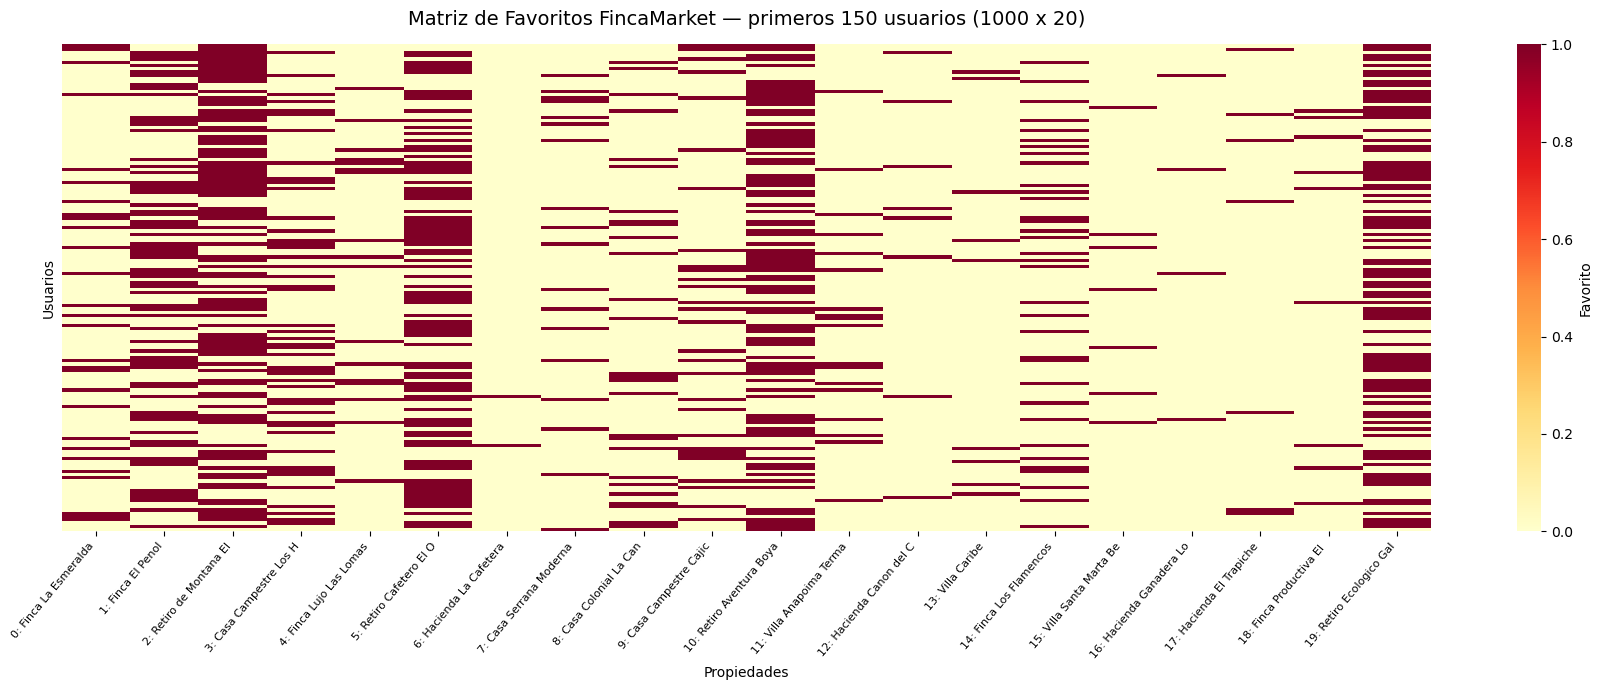

In [21]:
# Visualización 1 — Heatmap de la matriz (primeros 150 usuarios)
fig, ax = plt.subplots(figsize=(18, 7))

short_names = [f'{i}: {p["name"][:20]}' for i, p in enumerate(PROPERTIES)]

sns.heatmap(
    R[:150, :],
    ax=ax,
    cmap='YlOrRd',
    cbar_kws={'label': 'Favorito'},
    linewidths=0.0,
    xticklabels=short_names,
    yticklabels=False,
)

ax.set_title('Matriz de Favoritos FincaMarket — primeros 150 usuarios (1000 x 20)', fontsize=14, pad=14)
ax.set_xlabel('Propiedades')
ax.set_ylabel('Usuarios')
plt.xticks(rotation=50, ha='right', fontsize=8)

# Líneas divisorias entre segmentos
boundaries = [0]
for n in list(N_USERS_PER_SEGMENT.values())[:5]:
    boundaries.append(boundaries[-1] + n)
for b in boundaries[1:]:
    if b <= 150:
        ax.axhline(y=b, color='#4e8a50', linewidth=1.2, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

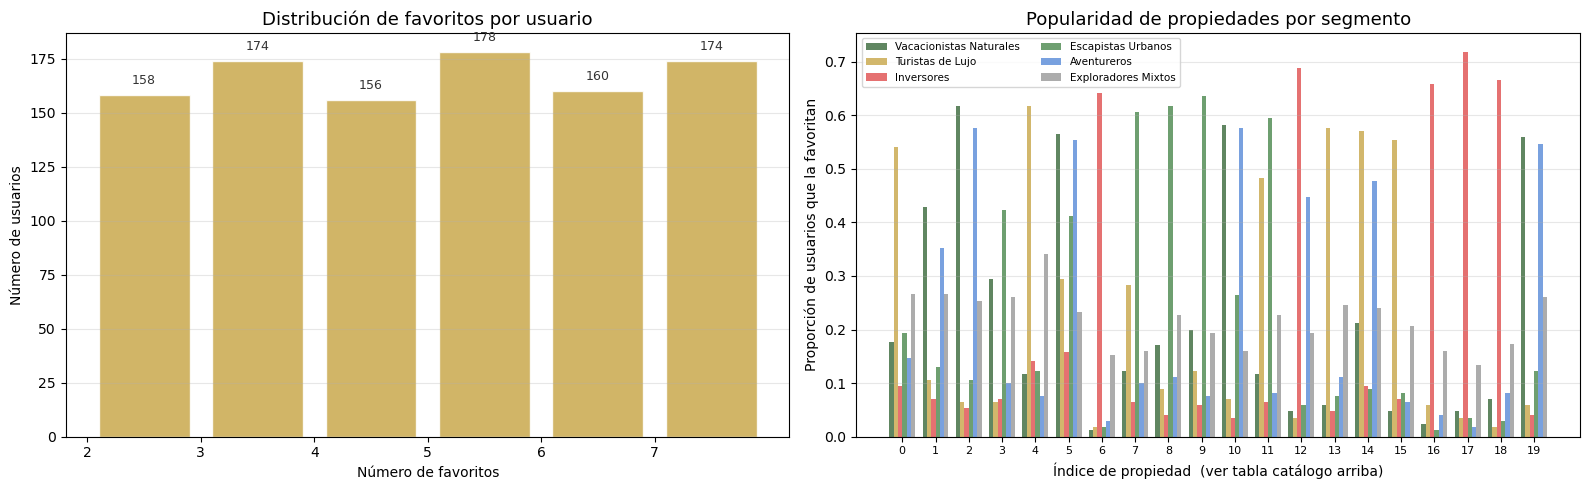

In [22]:
# Visualización 2 — Distribución de favoritos y popularidad por segmento
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- Panel izquierdo: histograma de favoritos por usuario --
axes[0].hist(user_n_favs, bins=range(2, 9), edgecolor='white',
             color='#c9a84c', alpha=0.85, rwidth=0.8)
axes[0].set_title('Distribución de favoritos por usuario', fontsize=13)
axes[0].set_xlabel('Número de favoritos')
axes[0].set_ylabel('Número de usuarios')
axes[0].set_xticks(range(2, 8))
axes[0].grid(axis='y', alpha=0.3)
for patch, x in zip(axes[0].patches, range(2, 8)):
    h = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2, h + 5, str(int(h)),
                 ha='center', fontsize=9, color='#333')

# -- Panel derecho: popularidad por segmento --
seg_labels = list(N_USERS_PER_SEGMENT.keys())
colors = ['#3d6b3e', '#c9a84c', '#e05252', '#4e8a50', '#5b8dd9', '#9a9a9a']
bar_w  = 0.13

for si, seg_name in enumerate(seg_labels):
    mask = user_segments == seg_name
    seg_pop = R[mask].mean(axis=0)
    x = np.arange(N_PROPS) + si * bar_w
    axes[1].bar(x, seg_pop, width=bar_w, label=seg_name, color=colors[si], alpha=0.82)

axes[1].set_xticks(np.arange(N_PROPS) + bar_w * 2.5)
axes[1].set_xticklabels([str(i) for i in range(N_PROPS)], fontsize=8)
axes[1].set_title('Popularidad de propiedades por segmento', fontsize=13)
axes[1].set_xlabel('Índice de propiedad  (ver tabla catálogo arriba)')
axes[1].set_ylabel('Proporción de usuarios que la favoritan')
axes[1].legend(fontsize=7.5, ncol=2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## PARTE 2 — Entrenamiento con TruncatedSVD

### Collaborative Filtering matricial

```
R  (1000×20)  ──TruncatedSVD──►  U (800×6) · Σ · Vt (6×20)
                                              ↓
                              item_factors = Vt.T  (20×6)
                                              ↓
   perfil_usuario = mean(item_factors[favoritos])  → vector (6,)
   scores         = perfil @ item_factors.T        → vector (20,)
```

### Split 80/20 por usuario
- **800 usuarios de entrenamiento** → SVD aprende los factores latentes
- **200 usuarios de test** → evaluación: se ocultan ~40% de sus favoritos y se mide si el modelo los recupera

In [23]:
# Split 80/20 por usuario
idx_all             = np.arange(N_USERS)
idx_train, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42)

R_train = R[idx_train]   # (800, 20)
R_test  = R[idx_test ]   # (200, 20)

print(f'Train : {R_train.shape[0]} usuarios')
print(f'Test  : {R_test.shape[0]}  usuarios')

# ── TruncatedSVD ──────────────────────────────────────────────────
N_COMPONENTS = 6
svd          = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
U_train      = svd.fit_transform(R_train)   # (800, 6)

# item_factors: representación latente de cada propiedad  (20, 6)
item_factors = svd.components_.T

print(f'\nitem_factors shape : {item_factors.shape}  (propiedades x factores)')
print(f'U_train shape      : {U_train.shape}         (usuarios_train x factores)')
print(f'\nVarianza explicada por componente:')

total = 0
for i, var in enumerate(svd.explained_variance_ratio_):
    total += var
    bar = '=' * int(var * 400)
    print(f'  Componente {i+1}:  {var:.3%}  {bar}  (acum. {total:.3%})')

Train : 800 usuarios
Test  : 200  usuarios

item_factors shape : (20, 6)  (propiedades x factores)
U_train shape      : (800, 6)         (usuarios_train x factores)

Varianza explicada por componente:
  Componente 1:  5.910%  =======================  (acum. 5.910%)
  Componente 2:  13.813%  =======================================================  (acum. 19.722%)
  Componente 3:  11.843%  ===============================================  (acum. 31.565%)
  Componente 4:  8.273%  =================================  (acum. 39.838%)
  Componente 5:  5.618%  ======================  (acum. 45.456%)
  Componente 6:  5.316%  =====================  (acum. 50.772%)


In [24]:
# ── Interpretación de los 6 factores latentes ─────────────────────
print('=' * 65)
print('  FACTORES LATENTES — QUE APRENDIO EL MODELO DE FINCAMARKET')
print('=' * 65)

# Etiquetas interpretativas (basadas en los segmentos que creamos)
FACTOR_LABELS = [
    'F1 — Demanda base (popularidad general del catalogo)',
    'F2 — Modalidad: Venta/inversion vs. Arriendo/vacacion',
    'F3 — Lujo Caribe vs. Retiros andinos economicos',
    'F4 — Naturaleza activa/aventura vs. Casas urbanas confort',
    'F5 — Antioquia premium vs. Cundinamarca/Bogota',
    'F6 — Haciendas grandes vs. Fincas medianas',
]

for fi, label in enumerate(FACTOR_LABELS):
    weights = item_factors[:, fi]
    top3_i  = np.argsort(weights)[::-1][:3]
    bot3_i  = np.argsort(weights)[:3]
    print(f'\n  {label}')
    print(f'  (+) {[prop_names[i][:28] for i in top3_i]}')
    print(f'  (-) {[prop_names[i][:28] for i in bot3_i]}')

print()
print('  Nota: los factores capturan las correlaciones reales entre')
print('  propiedades que el modelo descubrio en los patrones de favoritos.')
print('  Un usuario que "vive" en F2+ sera recomendado con haciendas de venta.')

  FACTORES LATENTES — QUE APRENDIO EL MODELO DE FINCAMARKET

  F1 — Demanda base (popularidad general del catalogo)
  (+) ['Retiro Cafetero El Origen', 'Retiro Aventura Boyaca', 'Retiro Ecologico Galeras']
  (-) ['Hacienda La Cafetera', 'Hacienda Ganadera Los Nogale', 'Hacienda El Trapiche']

  F2 — Modalidad: Venta/inversion vs. Arriendo/vacacion
  (+) ['Finca Productiva El Cedral', 'Hacienda Canon del Chicamoch', 'Hacienda El Trapiche']
  (-) ['Retiro Aventura Boyaca', 'Retiro Ecologico Galeras', 'Retiro de Montana El Silenci']

  F3 — Lujo Caribe vs. Retiros andinos economicos
  (+) ['Villa Anapoima Termal', 'Finca Lujo Las Lomas', 'Villa Santa Marta Bello']
  (-) ['Retiro Ecologico Galeras', 'Retiro de Montana El Silenci', 'Retiro Aventura Boyaca']

  F4 — Naturaleza activa/aventura vs. Casas urbanas confort
  (+) ['Finca Los Flamencos', 'Finca Lujo Las Lomas', 'Villa Caribe']
  (-) ['Casa Campestre Cajica', 'Casa Colonial La Candelaria', 'Casa Serrana Moderna']

  F5 — Antioquia p

In [25]:
# ── Evaluación: Precision@3 y Recall@3 ───────────────────────────
# Para cada usuario de test:
#   1. Ocultar ~40% de sus favoritos (min 1)
#   2. Reconstruir su perfil con los favoritos conocidos
#   3. Recomendar Top 3
#   4. Medir cuántos de los ocultos aparecen en las recomendaciones

def _reconstruir_perfil(known_idx):
    if len(known_idx) == 0:
        return np.zeros(N_COMPONENTS)
    return item_factors[known_idx].mean(axis=0)

precisions, recalls = [], []

rng_eval = np.random.default_rng(42)  # RNG independiente para reproducibilidad

for user_vec in R_test:
    liked = np.where(user_vec > 0)[0]
    if len(liked) < 2:
        continue

    n_hide = max(1, int(len(liked) * 0.4))
    perm   = rng_eval.permutation(liked)
    hidden = set(perm[:n_hide])
    known  = list(perm[n_hide:])

    profile = _reconstruir_perfil(known)
    scores  = item_factors @ profile
    scores[known] = -np.inf

    top3 = set(np.argsort(scores)[::-1][:3])
    hits = len(top3 & hidden)

    precisions.append(hits / 3)
    recalls.append(hits / len(hidden))

precision_at_3 = float(np.mean(precisions))
recall_at_3    = float(np.mean(recalls))

print('=' * 48)
print('  METRICAS DE EVALUACION — FincaMarket CF')
print('=' * 48)
print(f'  Precision@3  :  {precision_at_3:.4f}   ({precision_at_3:.2%})')
print(f'  Recall@3     :  {recall_at_3:.4f}   ({recall_at_3:.2%})')
print(f'  Usuarios eval:  {len(precisions)}')
print('=' * 48)
print()
print('  Precision@3: de cada 3 recomendaciones, cuantas son favoritos ocultos.')
print('  Recall@3   : de los favoritos ocultos, cuantos recuperamos en top 3.')
print('  Con datos sinteticos y segmentos bien definidos se espera > 15%.')

  METRICAS DE EVALUACION — FincaMarket CF
  Precision@3  :  0.2150   (21.50%)
  Recall@3     :  0.4150   (41.50%)
  Usuarios eval:  200

  Precision@3: de cada 3 recomendaciones, cuantas son favoritos ocultos.
  Recall@3   : de los favoritos ocultos, cuantos recuperamos en top 3.
  Con datos sinteticos y segmentos bien definidos se espera > 15%.


---
## PARTE 3 — Función de inferencia

```python
recomendar_propiedades(favoritos_usuario: list[str], top_n: int = 3) -> list[dict]
```

**Input:** lista de `trackId` en favoritos del usuario  
**Output:** top_n propiedades no favoriteadas, con `trackId · name · score · region · type · listingType · precio · amenities`  
**Cold start:** si lista vacía, devuelve top por rating promedio

In [26]:
def recomendar_propiedades(favoritos_usuario: list, top_n: int = 3) -> list:
    """
    Recomienda propiedades FincaMarket usando Collaborative Filtering (TruncatedSVD).

    Args:
        favoritos_usuario: lista de trackIds en favoritos.
        top_n: cuántas recomendaciones devolver.

    Returns:
        Lista de dicts con trackId, name, score, region, type,
        listingType, precio y amenities.
    """
    def _fmt_precio(p):
        if p['priceNight']:
            return f"COP {p['priceNight']:,}/noche"
        return f"COP {p['priceSale']:,} (venta)"

    def _build_result(idx_list, scores_arr):
        out = []
        for i in idx_list:
            prop = PROPERTIES[i]
            out.append({
                'trackId':     prop['trackId'],
                'name':        prop['name'],
                'score':       round(float(scores_arr[i]), 4),
                'region':      prop['region'],
                'type':        prop['type'],
                'listingType': prop['listingType'],
                'precio':      _fmt_precio(prop),
                'amenities':   prop['amenities'],
            })
        return out

    # ── Cold start: sin favoritos ──────────────────────────────────
    if not favoritos_usuario:
        ratings   = np.array([p['rating'] for p in PROPERTIES])
        top_idx   = np.argsort(ratings)[::-1][:top_n]
        return _build_result(top_idx, ratings)

    # ── Mapear trackIds a índices ──────────────────────────────────
    known_idx = [property_index[tid] for tid in favoritos_usuario
                 if tid in property_index]
    if not known_idx:
        return recomendar_propiedades([], top_n)  # fallback a cold start

    # ── Perfil del usuario en el espacio latente ───────────────────
    profile = item_factors[known_idx].mean(axis=0)  # (n_components,)

    # ── Score para todas las propiedades ──────────────────────────
    scores = item_factors @ profile  # (N_PROPS,)

    # ── Enmascarar las ya favoriteadas ────────────────────────────
    scores[known_idx] = -np.inf

    # ── Top-N ─────────────────────────────────────────────────────
    top_idx = np.argsort(scores)[::-1][:top_n]
    return _build_result(top_idx, scores)


print('recomendar_propiedades() definida correctamente.')

recomendar_propiedades() definida correctamente.


In [27]:
def _mostrar_recs(recs, caso, descripcion, favoritos):
    print('=' * 60)
    print(f'  {caso}: {descripcion}')
    print(f'  Favoritos input: {favoritos}')
    print('=' * 60)
    for k, r in enumerate(recs, 1):
        print(f'  {k}. {r["name"]}')
        print(f'     trackId     : {r["trackId"]}')
        print(f'     Score       : {r["score"]}')
        print(f'     Region/Tipo : {r["region"]} / {r["type"]} ({r["listingType"]})')
        print(f'     Precio      : {r["precio"]}')
        print(f'     Amenities   : {", ".join(r["amenities"])}')
        print()

# ── CASO A: Usuario antioqueño ─────────────────────────────────────
favs_a = ['finca-la-esmeralda', 'retiro-el-silencio']
recs_a = recomendar_propiedades(favs_a, top_n=3)
_mostrar_recs(recs_a, 'CASO A', 'Usuario antioqueño', favs_a)

  CASO A: Usuario antioqueño
  Favoritos input: ['finca-la-esmeralda', 'retiro-el-silencio']
  1. Finca El Penol
     trackId     : finca-el-penol
     Score       : 0.2485
     Region/Tipo : antioquia / finca (arriendo)
     Precio      : COP 520,000/noche
     Amenities   : Piscina, WiFi, Jacuzzi, Zona BBQ

  2. Retiro Ecologico Galeras
     trackId     : retiro-ecologico-galeras
     Score       : 0.1413
     Region/Tipo : narino / retiro (arriendo)
     Precio      : COP 360,000/noche
     Amenities   : WiFi, Rio/quebrada, Zona BBQ, Caballos

  3. Villa Santa Marta Bello
     trackId     : villa-santa-marta-bello
     Score       : 0.0867
     Region/Tipo : caribe / finca (arriendo)
     Precio      : COP 950,000/noche
     Amenities   : Piscina, WiFi, Jacuzzi, Zona BBQ



In [28]:
# ── CASO B: Inversor de haciendas ──────────────────────────────────
favs_b = ['hacienda-la-cafetera', 'hacienda-canon-chicamocha']
recs_b = recomendar_propiedades(favs_b, top_n=3)
_mostrar_recs(recs_b, 'CASO B', 'Inversor de haciendas', favs_b)

  CASO B: Inversor de haciendas
  Favoritos input: ['hacienda-la-cafetera', 'hacienda-canon-chicamocha']
  1. Finca Productiva El Cedral
     trackId     : finca-productiva-el-cedral
     Score       : 0.2126
     Region/Tipo : tolima / hacienda (venta)
     Precio      : COP 1,900,000,000 (venta)
     Amenities   : Caballos, WiFi, Zona BBQ, Rio/quebrada

  2. Hacienda El Trapiche
     trackId     : hacienda-el-trapiche
     Score       : 0.191
     Region/Tipo : valle / hacienda (venta)
     Precio      : COP 4,200,000,000 (venta)
     Amenities   : Piscina, WiFi, Caballos, Zona BBQ, Jacuzzi

  3. Hacienda Ganadera Los Nogales
     trackId     : hacienda-ganadera-los-nogales
     Score       : 0.1819
     Region/Tipo : caribe / hacienda (venta)
     Precio      : COP 5,500,000,000 (venta)
     Amenities   : Piscina, WiFi, Caballos, Zona BBQ



In [29]:
# ── CASO C: Playero caribeño ───────────────────────────────────────
favs_c = ['villa-caribe-cartagena', 'villa-santa-marta-bello']
recs_c = recomendar_propiedades(favs_c, top_n=3)
_mostrar_recs(recs_c, 'CASO C', 'Playero caribeno (lujo costero)', favs_c)

  CASO C: Playero caribeno (lujo costero)
  Favoritos input: ['villa-caribe-cartagena', 'villa-santa-marta-bello']
  1. Finca Lujo Las Lomas
     trackId     : finca-lujo-las-lomas
     Score       : 0.1968
     Region/Tipo : antioquia / finca (arriendo)
     Precio      : COP 850,000/noche
     Amenities   : Piscina, WiFi, Jacuzzi, Zona BBQ, Caballos

  2. Finca La Esmeralda
     trackId     : finca-la-esmeralda
     Score       : 0.1661
     Region/Tipo : antioquia / finca (arriendo)
     Precio      : COP 680,000/noche
     Amenities   : Piscina, WiFi, Zona BBQ, Caballos, Rio/quebrada

  3. Finca Los Flamencos
     trackId     : finca-los-flamencos
     Score       : 0.1485
     Region/Tipo : caribe / finca (arriendo)
     Precio      : COP 750,000/noche
     Amenities   : Piscina, WiFi, Rio/quebrada, Zona BBQ



In [30]:
# ── CASO D: Cold start — usuario nuevo sin favoritos ───────────────
recs_d = recomendar_propiedades([], top_n=3)
_mostrar_recs(recs_d, 'CASO D', 'Cold start (sin favoritos -> top por rating)', [])

  CASO D: Cold start (sin favoritos -> top por rating)
  Favoritos input: []
  1. Finca Lujo Las Lomas
     trackId     : finca-lujo-las-lomas
     Score       : 4.9
     Region/Tipo : antioquia / finca (arriendo)
     Precio      : COP 850,000/noche
     Amenities   : Piscina, WiFi, Jacuzzi, Zona BBQ, Caballos

  2. Retiro Cafetero El Origen
     trackId     : retiro-cafetero-el-origen
     Score       : 4.9
     Region/Tipo : eje-cafetero / retiro (arriendo)
     Precio      : COP 580,000/noche
     Amenities   : WiFi, Zona BBQ, Caballos, Rio/quebrada

  3. Retiro de Montana El Silencio
     trackId     : retiro-el-silencio
     Score       : 4.9
     Region/Tipo : antioquia / retiro (arriendo)
     Precio      : COP 390,000/noche
     Amenities   : WiFi, Zona BBQ, Rio/quebrada, Caballos



---
## PARTE 4 — Exportación con joblib

El paquete serializado `fincamarket_recommender.pkl` contiene todo lo necesario para inferencia en producción sin reentrenar:

| Campo | Descripción |
|-------|-------------|
| `svd_model` | TruncatedSVD ajustado |
| `item_factors` | Matriz (20×6) — representación latente de cada propiedad |
| `property_index` | Dict `trackId → índice` |
| `properties_data` | Lista completa de las 20 propiedades |
| `metadata` | n_users, n_components, fecha, métricas |

In [31]:
recommender_pkg = {
    'svd_model':       svd,
    'item_factors':    item_factors,
    'property_index':  property_index,
    'properties_data': PROPERTIES,
    'metadata': {
        'n_users':          N_USERS,
        'n_components':     N_COMPONENTS,
        'fecha':            str(date.today()),
        'precision_at_3':   round(precision_at_3, 4),
        'recall_at_3':      round(recall_at_3, 4),
        'catalog_version':  'v2.0 — 20 propiedades',
        'segments':         list(N_USERS_PER_SEGMENT.keys()),
    }
}

output_path = 'fincamarket_recommender.pkl'
joblib.dump(recommender_pkg, output_path, compress=3)

import os
size_kb = os.path.getsize(output_path) / 1024
print(f'Modelo exportado: {output_path}')
print(f'Tamanio en disco: {size_kb:.1f} KB')

Modelo exportado: fincamarket_recommender.pkl
Tamanio en disco: 2.7 KB


In [32]:
# ── Verificación: cargar y hacer inferencia desde el pkl ──────────
pkg = joblib.load(output_path)

print('Contenido del pkl:')
for k, v in pkg.items():
    if k == 'metadata':
        print(f'  metadata:')
        for mk, mv in v.items():
            print(f'    {mk:20s}: {mv}')
    elif hasattr(v, 'shape'):
        print(f'  {k:20s}: np.array {v.shape}')
    elif isinstance(v, dict):
        print(f'  {k:20s}: dict  ({len(v)} entradas)')
    elif isinstance(v, list):
        print(f'  {k:20s}: list  ({len(v)} items)')
    else:
        print(f'  {k:20s}: {type(v).__name__}')

# Inferencia de prueba con el modelo cargado
print()
print('Prueba de inferencia post-carga:')
pi   = pkg['property_index']
ifl  = pkg['item_factors']
pd_  = pkg['properties_data']

test_favs = ['retiro-aventura-boyaca', 'retiro-el-silencio', 'retiro-ecologico-galeras']
known     = [pi[t] for t in test_favs if t in pi]
profile   = ifl[known].mean(axis=0)
scores    = ifl @ profile
scores[known] = -np.inf
top3_ids  = [pd_[i]['trackId'] for i in np.argsort(scores)[::-1][:3]]

print(f'  Input  -> {test_favs}')
print(f'  Output -> {top3_ids}')
print()
print('PKL verificado correctamente. Notebook completado.')

Contenido del pkl:
  svd_model           : TruncatedSVD
  item_factors        : np.array (20, 6)
  property_index      : dict  (20 entradas)
  properties_data     : list  (20 items)
  metadata:
    n_users             : 1000
    n_components        : 6
    fecha               : 2026-05-20
    precision_at_3      : 0.215
    recall_at_3         : 0.415
    catalog_version     : v2.0 — 20 propiedades
    segments            : ['Vacacionistas Naturales', 'Turistas de Lujo', 'Inversores', 'Escapistas Urbanos', 'Aventureros', 'Exploradores Mixtos']

Prueba de inferencia post-carga:
  Input  -> ['retiro-aventura-boyaca', 'retiro-el-silencio', 'retiro-ecologico-galeras']
  Output -> ['finca-el-penol', 'casa-los-helechos', 'finca-los-flamencos']

PKL verificado correctamente. Notebook completado.
